# Lead Scoring End-to-End Project Notebook
This notebook demonstrates a full end-to-end workflow for the lead scoring project, including data import, exploratory analysis, feature engineering, model development, comparison, and scoring pipeline execution.

## 1. Project Setup and Dependencies
Install and import required packages, configure the notebook environment, and define repository paths.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from src.end_to_end_pipeline import run_end_to_end_pipeline, canonicalize_columns, ensure_canonical_features, score_frame

pd.options.display.max_columns = None
sns.set(style='whitegrid')

print('Project root:', PROJECT_ROOT)
print('Python executable:', sys.executable)
print('Pandas version:', pd.__version__)

Project root: C:\Users\oha14\Projects\Business Prediction\leadscoring
Python executable: c:\Users\oha14\AppData\Local\anaconda3\python.exe
Pandas version: 2.3.3


## 2. Load and Inspect Data
Load raw lead data from the repository and inspect the schema, sample rows, and missing values.

In [3]:
data_dir = PROJECT_ROOT / 'data' / 'raw'
lead_path = data_dir / 'lead.csv'

assert lead_path.exists(), f'Missing expected dataset: {lead_path}'

lead_df = pd.read_csv(lead_path)
print('Lead dataset shape:', lead_df.shape)
print('Columns:', lead_df.columns.tolist())

print('\nSample rows:')
display(lead_df.head())

print('\nMissing values:')
print(lead_df.isna().sum())


Lead dataset shape: (14000, 14)
Columns: ['id', 'first_name', 'last_name', 'company', 'email', 'phone', 'status', 'lead_source', 'owner_id', 'created_date', 'is_converted', 'converted_account_id', 'converted_contact_id', 'converted_opportunity_id']

Sample rows:


,id,first_name,last_name,company,email,phone,status,lead_source,owner_id,created_date,is_converted,converted_account_id,converted_contact_id,converted_opportunity_id
0,00QFZ0p4yMbuMejsyI,Jordan,Wong,Harbor Systems,jordan.wong.0@lead.example,+1-555-695-1876,Open,Web,005IAWyyPlUBLQDIva,2024-05-07,True,001PqnELu3Z5bJYo1m,003ZmchdR4224AuaPi,006UeBMQG0gkiBNu2o
1,00QaaO3OtUqFSZCP58,Jordan,Mitchell,BlueSky Group,jordan.mitchell.1@lead.example,+1-555-640-8745,Nurturing,Outbound,0052vuTGNhPaf9DJtR,2025-04-13,True,001RiqhXdyUJwIcFiW,003Yyhd45k8z1hDypd,006xRRAzeNl9gIM17f
2,00QgIX9oAT2XliVCRm,Jihoon,Taylor,Clearwater Services,jihoon.taylor.2@lead.example,+1-555-242-5972,Open,Partner Referral,005gvRs74Xd8fUlA3x,2023-12-27,False,NaN,NaN,NaN
3,00Q5CfGZnEgZ6YRPV8,Yara,Brown,Cobalt Health,yara.brown.3@lead.example,+1-555-405-4406,Nurturing,Outbound,005xi0Xi0wCwuciNbG,2025-04-28,True,0017GsD7Up46bIVCbY,003s68HbdjjxoVv3fI,006frH9g2CoWBe418J
4,00Q55Tgh78kMZqYwB5,Jada,Gupta,Harbor Financial,jada.gupta.4@lead.example,+1-555-210-4298,Nurturing,Outbound,005ATkmG7VSdpihf48,2022-06-12,True,001FbowpksOa9uGfrU,0038wyjOgdTsiHVR3T,006CWfOgyOTcBmaKHu



Missing values:
id                             0
first_name                     0
last_name                      0
company                        0
email                          0
phone                          0
status                         0
lead_source                    0
owner_id                       0
created_date                   0
is_converted                   0
converted_account_id        6635
converted_contact_id        7525
converted_opportunity_id    7525
dtype: int64


## 2.1 Preliminary Data Exploration with Visuals
Visualize the distribution of lead status, lead source, and conversion balance.

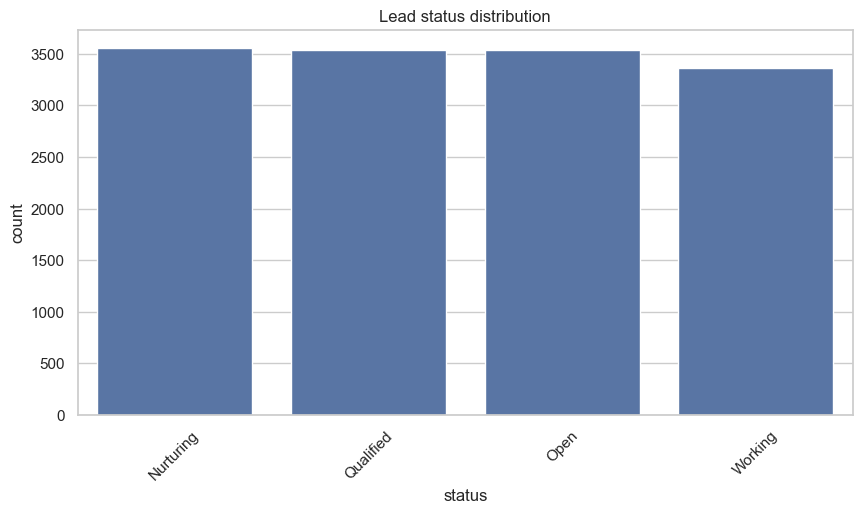

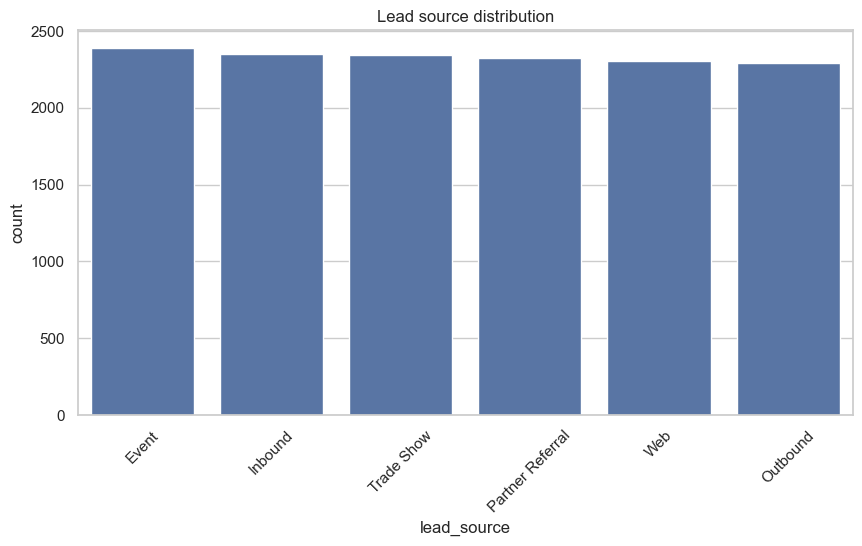

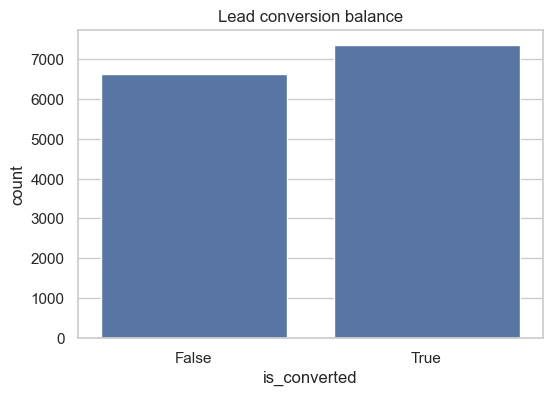

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(data=lead_df, x='status', order=lead_df['status'].value_counts().index)
plt.title('Lead status distribution')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=lead_df, x='lead_source', order=lead_df['lead_source'].value_counts().index)
plt.title('Lead source distribution')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=lead_df, x='is_converted')
plt.title('Lead conversion balance')
plt.show()

## 3. Data Analysis
Analyze conversion trends by categorical variables and compare conversion rates across groups.

Conversion rate overall:
is_converted
True     0.526071
False    0.473929
Name: proportion, dtype: float64


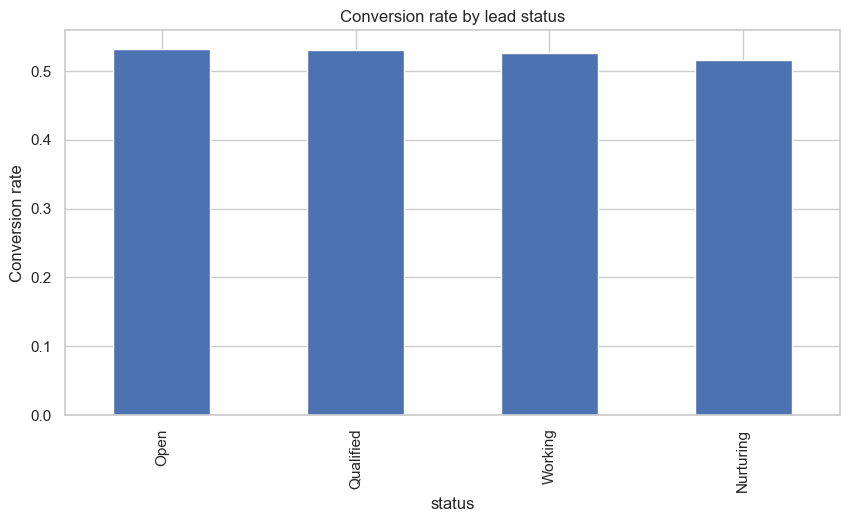

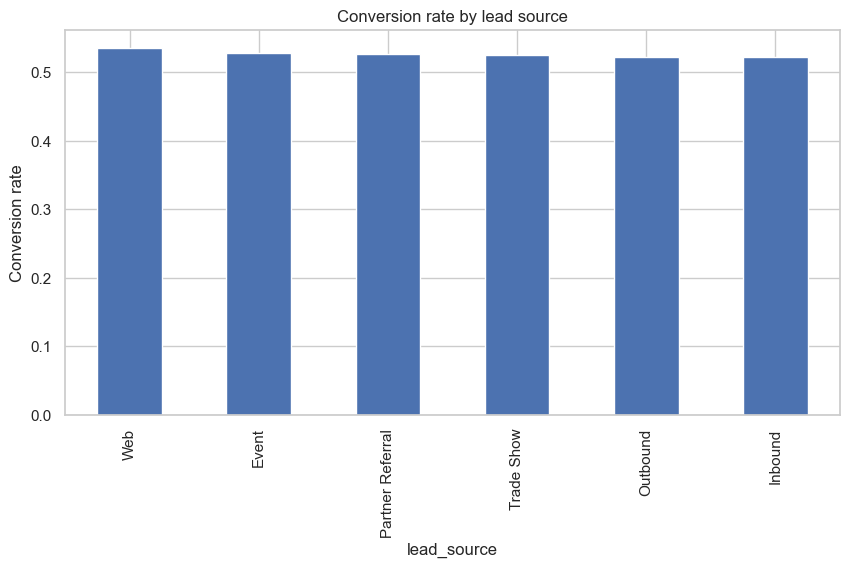

In [5]:
print('Conversion rate overall:')
print(lead_df['is_converted'].value_counts(normalize=True))

conversion_by_status = lead_df.groupby('status')['is_converted'].mean().sort_values(ascending=False)
conversion_by_source = lead_df.groupby('lead_source')['is_converted'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
conversion_by_status.plot(kind='bar')
plt.ylabel('Conversion rate')
plt.title('Conversion rate by lead status')
plt.show()

plt.figure(figsize=(10, 5))
conversion_by_source.plot(kind='bar')
plt.ylabel('Conversion rate')
plt.title('Conversion rate by lead source')
plt.show()

## 4. Feature Engineering
Create derived features from dates, text lengths, and categorical fields.

In [12]:
lead_df = canonicalize_columns(lead_df).copy()
lead_df['created_date'] = pd.to_datetime(lead_df['created_date'], errors='coerce')
lead_df['lead_age_days'] = (pd.Timestamp.today() - lead_df['created_date']).dt.days
lead_df['lead_age_days'] = lead_df['lead_age_days'].fillna(-1).astype(int)
lead_df['name_length'] = (lead_df['first_name'].fillna('') + ' ' + lead_df['last_name'].fillna('')).str.len()
lead_df['company_length'] = lead_df['company'].astype(str).fillna('').str.len()
lead_df['email_domain'] = (
    lead_df['email'].astype(str).str.split('@').str[-1].replace('nan', 'unknown').fillna('unknown')
)
owner_column = 'lead_owner_id' if 'lead_owner_id' in lead_df.columns else ('owner_id' if 'owner_id' in lead_df.columns else None)
lead_df['is_owner_present'] = lead_df[owner_column].notna().astype(int) if owner_column is not None else 0
lead_df['has_email'] = lead_df['email'].notna().astype(int)
lead_df['has_phone'] = lead_df['phone'].notna().astype(int)

feature_columns = [
    'status',
    'lead_source',
    'lead_age_days',
    'name_length',
    'company_length',
    'email_domain',
    'is_owner_present',
    'has_email',
    'has_phone',
]
target_column = 'is_converted'

display(lead_df[feature_columns + [target_column]].head())


,status,lead_source,lead_age_days,name_length,company_length,email_domain,is_owner_present,has_email,has_phone,is_converted
0,Open,Web,792,11,14,lead.example,1,1,1,True
1,Nurturing,Outbound,451,15,13,lead.example,1,1,1,True
2,Open,Partner Referral,924,13,19,lead.example,1,1,1,False
3,Nurturing,Outbound,436,10,13,lead.example,1,1,1,True
4,Nurturing,Outbound,1487,10,16,lead.example,1,1,1,True


## 5. Model Development and Comparison
Build and compare candidate models using cross-validated AUC.

In [13]:
X = lead_df[feature_columns].copy()
y = lead_df[target_column].astype(int).copy()

numeric_features = ['lead_age_days', 'name_length', 'company_length', 'is_owner_present']
cat_features = ['status', 'lead_source', 'email_domain']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, cat_features),
])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = []
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')
    results.append({'model': name, 'mean_auc': float(np.mean(scores)), 'std_auc': float(np.std(scores))})
    print(f'{name}: AUC = {np.mean(scores):.4f} ± {np.std(scores):.4f}')

results_df = pd.DataFrame(results).sort_values('mean_auc', ascending=False)
display(results_df)


Logistic Regression: AUC = 0.4997 ± 0.0074
Random Forest: AUC = 0.5075 ± 0.0086
Gradient Boosting: AUC = 0.5035 ± 0.0052


,model,mean_auc,std_auc
1,Random Forest,0.507545,0.008629
2,Gradient Boosting,0.503500,0.005208
0,Logistic Regression,0.499682,0.007353


## 6. Choose the Best Model
Train the selected model on a holdout split and evaluate on test data.

Best model selected: Random Forest
Test AUC: 0.5007728653380782
Classification report:
              precision    recall  f1-score   support

           0       0.47      0.46      0.47      1659
           1       0.52      0.53      0.52      1841

    accuracy                           0.50      3500
   macro avg       0.50      0.50      0.50      3500
weighted avg       0.50      0.50      0.50      3500



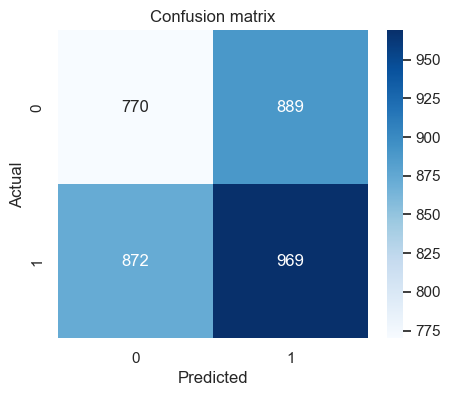

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

best_model_name = results_df.iloc[0]['model']
best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', best_model)])
best_pipeline.fit(X_train, y_train)

preds = best_pipeline.predict(X_test)
probs = best_pipeline.predict_proba(X_test)[:, 1]

print(f'Best model selected: {best_model_name}')
print('Test AUC:', roc_auc_score(y_test, probs))
print('Classification report:')
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.show()

## 7. Model Explainability
This section builds an explainability layer for the chosen model.

- It first tries to use SHAP to generate a summary explanation of how each feature affects prediction.
- If SHAP is unavailable, it falls back to the model's built-in importance metrics:
  - `feature_importances_` for tree-based models
  - `coef_` for linear models
- It also reconstructs the one-hot encoded feature names so the explanations refer to human-readable inputs.

After running the explainability cell, use the output to answer these questions:
1. Which features are most important for predicting conversion?
2. For SHAP, note whether a feature increases or decreases predicted probability.
3. For coefficient-based results, positive values mean a higher conversion score when the feature is present, while negative values mean a lower score.
4. For one-hot encoded categorical features, each value (for example `status_open`) is treated separately.

Explainability layer using feature names:
['lead_age_days', 'name_length', 'company_length', 'is_owner_present', 'status_Nurturing', 'status_Open', 'status_Qualified', 'status_Working', 'lead_source_Event', 'lead_source_Inbound'] ... total 15
SHAP is not installed in this environment; using model-specific importance metrics instead.


,feature,importance
0,lead_age_days,0.577433
2,company_length,0.213763
1,name_length,0.157095
13,lead_source_Web,0.005697
12,lead_source_Trade Show,0.005666
9,lead_source_Inbound,0.005575
10,lead_source_Outbound,0.005224
11,lead_source_Partner Referral,0.005096
7,status_Working,0.005078
6,status_Qualified,0.005035


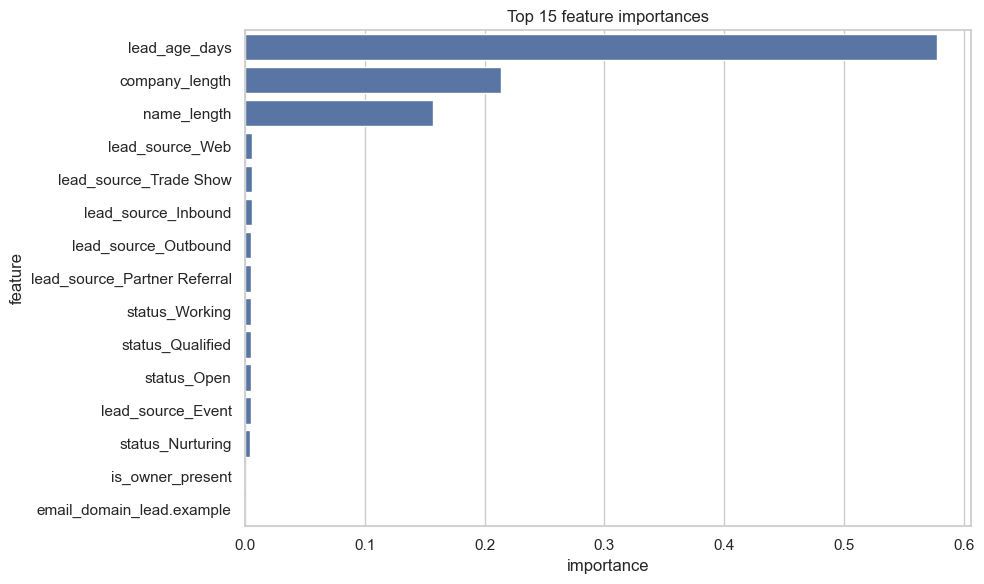


Interpreting feature importance:
- Higher importance means the feature has more influence on model decisions.
- This does not show direction, only relative strength.


In [19]:
# Try to import SHAP for model-agnostic explanation
try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False

# Extract the fitted pipeline components used for prediction
fitted_preprocessor = best_pipeline.named_steps['preprocessor']
model = best_pipeline.named_steps['model']

# Reuse the same feature groups that were used to build the pipeline
numeric_features = ['lead_age_days', 'name_length', 'company_length', 'is_owner_present']
cat_features = ['status', 'lead_source', 'email_domain']

# Reconstruct the output feature names for the one-hot encoder
cat_transformer = fitted_preprocessor.named_transformers_['cat']
ohe = cat_transformer.named_steps['onehot']
if hasattr(ohe, 'get_feature_names_out'):
    encoded_cat_names = list(ohe.get_feature_names_out(cat_features))
else:
    encoded_cat_names = [
        f'{feat}_{val}'
        for feat, vals in zip(cat_features, ohe.categories_)
        for val in vals
    ]

feature_names = numeric_features + encoded_cat_names
print('Explainability layer using feature names:')
print(feature_names[:10], '... total', len(feature_names))

# Use SHAP when available to create a global explanation plot
if shap_available:
    X_test_transformed = fitted_preprocessor.transform(X_test)
    explainer = shap.Explainer(model, X_test_transformed, feature_names=feature_names)
    shap_values = explainer(X_test_transformed)

    shap.summary_plot(
        shap_values,
        features=X_test_transformed,
        feature_names=feature_names,
        show=False,
    )
    plt.title('SHAP summary plot for the selected model')
    plt.tight_layout()
    plt.show()

    print('\nInterpreting SHAP results:')
    print('- Features shown at the top are the most important.')
    print('- Red points indicate a feature value that pushes predictions higher.')
    print('- Blue points indicate a feature value that pushes predictions lower.')
    print('- Spread indicates how much the feature changes the score across leads.')
else:
    # Fallback to model-provided importances or coefficients
    print('SHAP is not installed in this environment; using model-specific importance metrics instead.')
    if hasattr(model, 'feature_importances_'):
        importance_values = model.feature_importances_
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importance_values,
        }).sort_values('importance', ascending=False)

        display(importance_df.head(15))
        plt.figure(figsize=(10, 6))
        sns.barplot(data=importance_df.head(15), x='importance', y='feature')
        plt.title('Top 15 feature importances')
        plt.tight_layout()
        plt.show()

        print('\nInterpreting feature importance:')
        print('- Higher importance means the feature has more influence on model decisions.')
        print('- This does not show direction, only relative strength.')
    elif hasattr(model, 'coef_'):
        coef_values = model.coef_[0]
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': coef_values,
        }).assign(abs_coef=lambda df: np.abs(df['coefficient'])).sort_values('abs_coef', ascending=False)

        display(coef_df[['feature', 'coefficient']].head(15))
        plt.figure(figsize=(10, 6))
        sns.barplot(data=coef_df.head(15), x='coefficient', y='feature')
        plt.title('Top 15 model coefficients')
        plt.tight_layout()
        plt.show()

        print('\nInterpreting coefficients:')
        print('- Positive coefficients increase predicted conversion probability.')
        print('- Negative coefficients decrease predicted conversion probability.')
        print('- Larger absolute values mean stronger effect.')
    else:
        print('The selected model does not expose feature importances or coefficients for direct explainability.')

## 8. Run the Business Scoring Pipeline
Execute the repository scoring pipeline on the raw lead dataset and save the results.

In [15]:
output_path = PROJECT_ROOT / 'reports' / 'end_to_end_notebook_scored_leads_copy.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
scored_business_df = run_end_to_end_pipeline(lead_path, output_path)
print('Saved business scoring output to:', output_path)

print('Business scoring pipeline preview:')
display(scored_business_df[['priority_score', 'priority_bucket', 'recommended_action']].head())

Saved business scoring output to: C:\Users\oha14\Projects\Business Prediction\leadscoring\reports\end_to_end_notebook_scored_leads_copy.csv
Business scoring pipeline preview:


,priority_score,priority_bucket,recommended_action
0,60.937679,Hot,Contact today
1,60.937679,Hot,Contact today
2,60.937679,Hot,Contact today
3,60.937679,Hot,Contact today
4,60.937679,Hot,Contact today


## 9. Analyze Output and Compare Results
Compare the supervised model probability with the business scoring pipeline results.

In [16]:
if 'priority_score' in scored_business_df.columns:
    display(scored_business_df['priority_score'].describe())

if 'priority_bucket' in scored_business_df.columns:
    display(scored_business_df['priority_bucket'].value_counts())

comparison_df = lead_df.copy()
comparison_df['model_probability'] = best_pipeline.predict_proba(X)[:, 1]
if 'priority_score' in scored_business_df.columns:
    comparison_df = comparison_df.merge(
        scored_business_df[['id', 'priority_score', 'priority_bucket']],
        on='id',
        how='left',
    )

print('Comparison sample records:')
display(comparison_df[['id', 'status', 'lead_source', 'lead_age_days', 'is_converted', 'model_probability', 'priority_score', 'priority_bucket']].head())

count    14000.000000
mean        55.903860
std          3.003043
min         49.037679
25%         53.325179
50%         56.037679
75%         58.487679
max         60.937679
Name: priority_score, dtype: float64

priority_bucket
Cold    3582
Hot     3513
Cool    3469
Warm    3436
Name: count, dtype: int64

Comparison sample records:


,id,status,lead_source,lead_age_days,is_converted,model_probability,priority_score,priority_bucket
0,00QFZ0p4yMbuMejsyI,Open,Web,792,True,0.85,55.600179,Cool
1,00QaaO3OtUqFSZCP58,Nurturing,Outbound,451,True,0.35,49.037679,Cold
2,00QgIX9oAT2XliVCRm,Open,Partner Referral,924,False,0.24,57.437679,Warm
3,00Q5CfGZnEgZ6YRPV8,Nurturing,Outbound,436,True,0.73,49.037679,Cold
4,00Q55Tgh78kMZqYwB5,Nurturing,Outbound,1487,True,0.72,49.037679,Cold


## 10. Conclusion and Next Steps
Summarize findings and define key next actions for the project deployment.

- Imported and explored the raw lead dataset, confirming the target variable and input fields.
- Performed EDA showing how status and source relate to conversion probability.
- Engineered date, text, and categorical features for modeling.
- Compared Logistic Regression, Random Forest, and Gradient Boosting using cross-validated AUC.
- Selected the best model, validated it on a holdout test split, and evaluated performance.
- Added a model explainability layer to identify top predictors and support transparency.
- Ran the repository scoring pipeline and compared its business priority output with the model probability.

Next steps:
1. Enrich the feature set using additional raw files like account, tasks, and user.
2. Tune the chosen model and calibrate thresholds for business actions.
3. Deploy the final scoring model into the Streamlit app and monitor performance.